# CE49X Lab 6: Can We Predict Heart Disease?
## Machine Learning for Medical Diagnosis

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

---

**Student Name:**  
**Student ID:**  
**AI Assistance:** *(Document any AI tools used and how)*

## Background

Cardiovascular diseases are the **leading cause of death globally**, responsible for approximately 17.9 million deaths per year (WHO, 2021). Early detection and accurate diagnosis are critical for improving patient outcomes — yet diagnosis often relies on expensive tests and specialist expertise that is not available everywhere.

Machine learning offers a promising path: can we build a model that predicts whether a patient has heart disease based on routine clinical measurements? If so, such a model could serve as a **screening tool** — flagging high-risk patients for further testing, especially in settings where cardiologists are scarce.

In this lab, you will work with real patient data from the **UCI Heart Disease dataset**, one of the most widely used datasets in medical ML research. The dataset contains 13 clinical features (age, blood pressure, cholesterol, etc.) and a binary label indicating whether heart disease was diagnosed.

> **Key Insight:** This is a **high-stakes classification problem**. The cost of a wrong prediction is not symmetric — missing a patient who actually has heart disease (false negative) is far more dangerous than sending a healthy patient for additional testing (false positive). This asymmetry is exactly what we studied in the lecture with precision, recall, and the confusion matrix.

## Scenario

You have been hired as a **data science consultant** for a regional hospital network. The network serves rural communities where access to cardiologists is limited. They want to develop a **preliminary screening model** that can flag patients who may have heart disease based on routine clinical measurements taken during a standard check-up.

Your task is to:
1. Explore and understand the clinical data
2. Train and compare classification models
3. Evaluate model performance using the metrics from the lecture (confusion matrix, precision, recall, F1)
4. Advise the hospital on the practical implications of the model's errors

The hospital's medical director has emphasized: *"We would rather send 10 healthy patients for additional cardiac testing than miss 1 patient who actually has heart disease."*

## Dataset Description

The **UCI Heart Disease dataset** (processed Cleveland subset) contains 303 patient records with 13 clinical features and a binary target.

| Feature | Description | Type |
|---------|-------------|------|
| `age` | Age in years | Numeric |
| `sex` | Sex (1 = male, 0 = female) | Binary |
| `cp` | Chest pain type (0–3) | Categorical (integer-coded) |
| `trestbps` | Resting blood pressure (mm Hg) | Numeric |
| `chol` | Serum cholesterol (mg/dl) | Numeric |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = true, 0 = false) | Binary |
| `restecg` | Resting ECG results (0–2) | Categorical (integer-coded) |
| `thalach` | Maximum heart rate achieved during exercise | Numeric |
| `exang` | Exercise-induced angina (1 = yes, 0 = no) | Binary |
| `oldpeak` | ST depression induced by exercise relative to rest | Numeric |
| `slope` | Slope of peak exercise ST segment (0–2) | Categorical (integer-coded) |
| `ca` | Number of major vessels colored by fluoroscopy (0–3) | Numeric |
| `thal` | Thalassemia (0 = normal, 1 = fixed defect, 2 = reversible defect) | Categorical (integer-coded) |
| **`target`** | **Heart disease diagnosis (1 = disease, 0 = no disease)** | **Binary** |

> **Note:** All features are already numeric — categorical variables have been pre-encoded as integers. You do **not** need to perform any encoding for this lab. Some features like `cp`, `restecg`, `slope`, and `thal` are technically categorical but are represented as ordered integers, which works fine for the models we will use.

## Deliverables Overview

| # | Title | Points | Key Techniques |
|---|-------|--------|----------------|
| D1 | Data Loading & Exploration | 20 | `pd.read_csv`, `df.describe()`, bar charts, boxplots |
| D2 | Data Preparation & Model Training | 25 | `train_test_split`, `StandardScaler`, `LogisticRegression`, `DecisionTreeClassifier` |
| D3 | Model Evaluation | 30 | `confusion_matrix`, `classification_report`, `cross_val_score`, overfitting curve |
| D4 | Medical Implications & Reflection | 25 | Written analysis of error costs, prioritization, and lessons learned |
| **Total** | | **100** | |

**Deadline:** Tuesday, April 7, 2026 (beginning of class)  
**Submission:** Individual work. Rename this notebook to `Week06_Lab_FirstnameLastname.ipynb`, commit and push to your fork.

---
## Your Work Starts Here

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, f1_score)
import time
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

---
## Deliverable 1: Data Loading & Exploration (20 pts)

### Instructions

1. **Load the dataset** using the code cell below (it downloads directly from the UCI repository — no signup needed)
2. **Explore the data:**
   - Print `df.shape`, `df.info()`, and `df.describe()`
   - Check for missing values
3. **Create at least 3 visualizations:**
   - A bar chart showing the distribution of the target variable (how many patients have heart disease vs. don't)
   - At least 1 plot exploring a **numeric feature** across the two classes (e.g., boxplot of `age` grouped by `target`, or histogram of `thalach` colored by diagnosis)
   - At least 1 plot exploring a **second feature** of your choice (e.g., bar chart of `cp` counts by target, scatter plot of `age` vs `thalach` colored by target)
4. **Written observation** (1 paragraph in a markdown cell): What patterns do you notice? Which features seem related to heart disease?

| Criterion | Points |
|---|---|
| Data loaded, shape and info printed | 3 |
| Missing values checked and handled | 3 |
| 3+ well-labeled exploration plots | 8 |
| Written observation paragraph | 6 |

> **Key Insight:** The target variable is roughly balanced (~54% no disease, ~46% disease). This means a model that always predicts "no disease" would only be right about 54% of the time. Keep this baseline in mind — any useful model must beat it.

In [3]:
# Load the UCI Heart Disease dataset (Cleveland subset)
# This downloads directly from the UCI ML Repository - no account needed

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv(url, names=columns, na_values='?')

# The original target has values 0-4 (severity levels).
# We binarize: 0 = no heart disease, 1 = heart disease present
df['target'] = (df['target'] > 0).astype(int)

# TIP: If the URL doesn't work, download the file manually from
# https://archive.ics.uci.edu/dataset/45/heart+disease
# Save it as 'data/processed.cleveland.data' and load with:
# df = pd.read_csv('data/processed.cleveland.data', names=columns, na_values='?')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [28]:
# Your exploration here: df.info(), df.describe(), missing values check
# Option 2: print describe as text
df.info()
print("-" * 50)
print("\nSummary statistics:")
print(df.describe())
print("-" * 50)
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
--------------------------------------------------

Summary statistics:
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000 

Patients with NO heart disease (target=0): 164
Patients WITH heart disease (target=1): 139


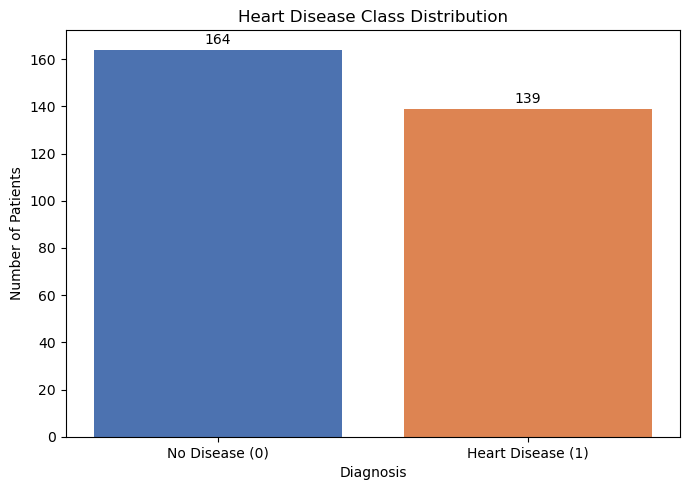

In [29]:
# Plot 1: Target variable distribution (bar chart)
target_counts = df['target'].value_counts().sort_index()

no_disease = int(target_counts.get(0, 0))
heart_disease = int(target_counts.get(1, 0))

print(f"Patients with NO heart disease (target=0): {no_disease}")
print(f"Patients WITH heart disease (target=1): {heart_disease}")

labels = ['No Disease (0)', 'Heart Disease (1)']
values = [no_disease, heart_disease]

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, values, color=['#4C72B0', '#DD8452'])
plt.title('Heart Disease Class Distribution')
plt.xlabel('Diagnosis')
plt.ylabel('Number of Patients')

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 1, str(val),
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

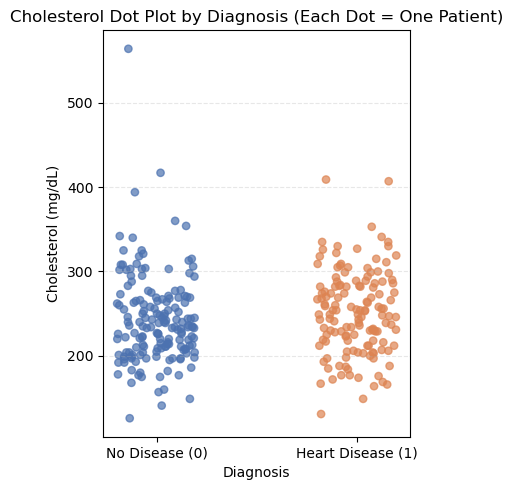

In [25]:
# Plot 2: Dot plot of cholesterol (each dot = one person)
chol_df = df[['target', 'chol']].dropna().copy()

# Small horizontal jitter so overlapping points are visible
np.random.seed(42)
jitter = np.random.uniform(-0.2, 0.2, size=len(chol_df))
x_positions = chol_df['target'].values + jitter

colors = np.where(chol_df['target'].values == 0, '#4C72B0', '#DD8452')

plt.figure(figsize=(4, 5))
plt.scatter(x_positions, chol_df['chol'].values, c=colors, alpha=0.7, s=28)
plt.xticks([0, 1], ['No Disease (0)', 'Heart Disease (1)'])
plt.xlabel('Diagnosis')
plt.ylabel('Cholesterol (mg/dL)')
plt.title('Cholesterol Dot Plot by Diagnosis (Each Dot = One Patient)')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

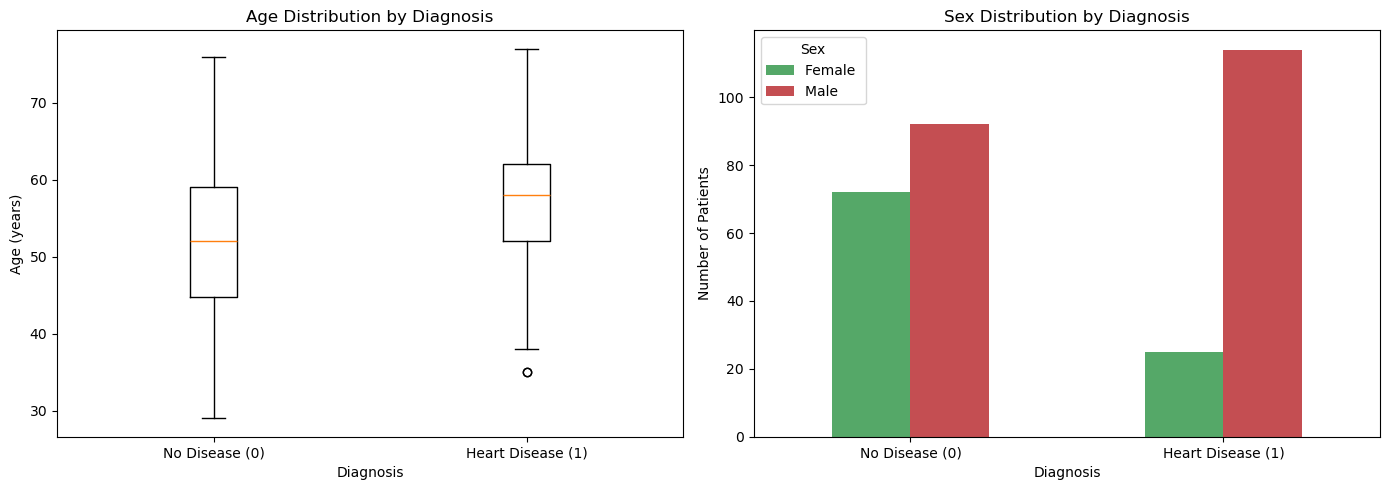

In [26]:
# Plot 3: Age and sex distribution across diseased and normal persons
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: age distribution by target
age_groups = [df[df['target'] == 0]['age'].dropna(),
              df[df['target'] == 1]['age'].dropna()]
axes[0].boxplot(age_groups, labels=['No Disease (0)', 'Heart Disease (1)'])
axes[0].set_title('Age Distribution by Diagnosis')
axes[0].set_xlabel('Diagnosis')
axes[0].set_ylabel('Age (years)')

# Right plot: sex distribution by target
sex_target_counts = pd.crosstab(df['target'], df['sex'])
sex_target_counts.columns = ['Female ', 'Male ']
sex_target_counts.index = ['No Disease (0)', 'Heart Disease (1)']
sex_target_counts.plot(kind='bar', ax=axes[1], color=['#55A868', '#C44E52'])
axes[1].set_title('Sex Distribution by Diagnosis')
axes[1].set_xlabel('Diagnosis')
axes[1].set_ylabel('Number of Patients')
axes[1].legend(title='Sex')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Observation

*Write your observation paragraph here. What patterns do you notice in the data? Which features seem most related to heart disease diagnosis?*

I analyzed the age, sex, and colestrol level.

Colestrol level seems very less relation with heart disease by itself. It may have maybe it is analyzed with another one.

People who have heart disease have higher age mean. So we can correlate it somehow that higher age people may have face heart disease

Being male seems increase the change of having heart disease by looking the graph alone

---
## Deliverable 2: Data Preparation & Model Training (25 pts)

### Instructions

1. **Handle missing values.** Drop any rows with missing values (there should be very few). Print the shape before and after.

2. **Separate features and target:**
   - `X` = all columns except `target`
   - `y` = the `target` column

3. **Train-test split:** Split into 80% training / 20% test using `train_test_split` with `stratify=y` and `random_state=42`. Print the shapes of `X_train`, `X_test`, `y_train`, `y_test`.

4. **Scale the features** using `StandardScaler`:
   - Fit the scaler on `X_train` only
   - Transform both `X_train` and `X_test`
   - **[REQUIRED] Markdown cell:** Why must we fit the scaler on the training data only? What would go wrong if we fit it on the entire dataset before splitting? *(Connect this to the data leakage concept from the lecture.)*

5. **Train two classifiers:**
   - `LogisticRegression(max_iter=1000, random_state=42)`
   - `DecisionTreeClassifier(random_state=42)`

6. For each model, report:
   - Training accuracy
   - Test accuracy
   - Training time (use `time.time()` before and after `model.fit()`)

7. **[REQUIRED] Markdown cell:** Create a comparison summary. Which model performs better on the test set? Is either model overfitting? How can you tell from the train vs. test accuracy gap?

| Criterion | Points |
|---|---|
| Missing values handled, shapes printed | 2 |
| Train-test split with stratification | 3 |
| Scaling done correctly (fit on train only) | 3 |
| Data leakage explanation (own words) | 4 |
| Both models trained, all metrics reported | 6 |
| Comparison + overfitting discussion | 7 |

> **Key Insight:** If your Decision Tree achieves near-100% training accuracy but much lower test accuracy, it has memorized the training data. This is overfitting — the central danger from Section 7 of the lecture. The gap between training and test accuracy is your overfitting signal.

In [4]:
# Handle missing values
print(f"Shape before dropping missing values: {df.shape}")
df = df.dropna()
print(f"Shape after dropping missing values: {df.shape}")

Shape before dropping missing values: (303, 14)
Shape after dropping missing values: (297, 14)


In [6]:
# Separate features (X) and target (y), then train-test split
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (237, 13)
X_test shape:  (60, 13)
y_train shape: (237,)
y_test shape:  (60,)


In [7]:
# Scale features with StandardScaler
# IMPORTANT: fit on X_train only, then transform both X_train and X_test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")

X_train_scaled shape: (237, 13)
X_test_scaled shape:  (60, 13)


We do the scaling because different features may have different ranges. So we scale them so that their values would be between 0 and 1.

### Data Leakage Explanation

We must fit the scaler only on the training data so the model learns from information that would be available at training time in a real deployment. If we fit the scaler on the full dataset first, the test set statistics (mean and standard deviation) leak into preprocessing.

That leakage makes evaluation overly optimistic, because the model indirectly gets information from the test set before prediction. This violates the train/test separation principle and gives a biased estimate of generalization performance.

In [8]:
# Train Logistic Regression and report metrics
log_reg = LogisticRegression(max_iter=1000, random_state=42)

start_time = time.time()
log_reg.fit(X_train_scaled, y_train)
log_reg_train_time = time.time() - start_time

log_reg_train_acc = log_reg.score(X_train_scaled, y_train)
log_reg_test_acc = log_reg.score(X_test_scaled, y_test)

print("Logistic Regression Results")
print(f"Training accuracy: {log_reg_train_acc:.4f}")
print(f"Test accuracy:     {log_reg_test_acc:.4f}")
print(f"Training time:     {log_reg_train_time:.4f} seconds")

Logistic Regression Results
Training accuracy: 0.8523
Test accuracy:     0.8333
Training time:     0.0512 seconds


In [10]:
# Train Decision Tree and report metrics
dec_tree = DecisionTreeClassifier(random_state=42)

start_time = time.time()
dec_tree.fit(X_train_scaled, y_train)
dec_tree_train_time = time.time() - start_time

dec_tree_train_acc = dec_tree.score(X_train_scaled, y_train)
dec_tree_test_acc = dec_tree.score(X_test_scaled, y_test)

print("Decision Tree Results")
print(f"Training accuracy: {dec_tree_train_acc:.4f}")
print(f"Test accuracy:     {dec_tree_test_acc:.4f}")
print(f"Training time:     {dec_tree_train_time:.4f} seconds")

Decision Tree Results
Training accuracy: 1.0000
Test accuracy:     0.6833
Training time:     0.0055 seconds


### Model Comparison

*Which model performs better on the test set? Is either model overfitting? How can you tell?*

Regression performs better at actual test. Altough decision tree takes the whole knowledge from the training data, it stays behind to apply the data into new data set. We can see the confusion matrix below.



Test Accuracy Results
Logistic Regression test accuracy: 0.8333
Decision Tree test accuracy:       0.6833


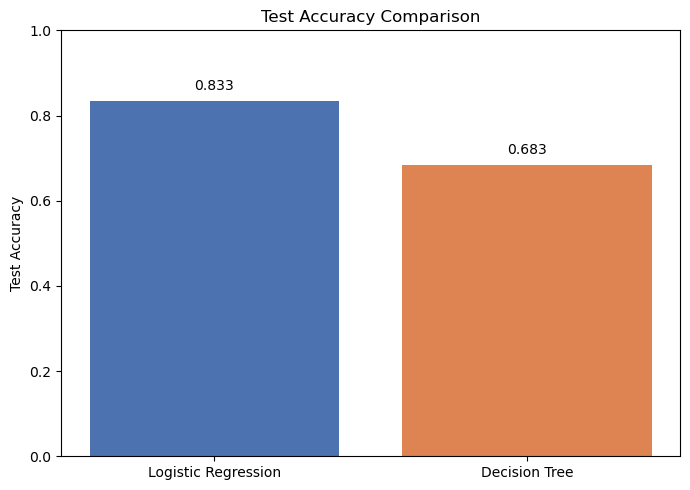

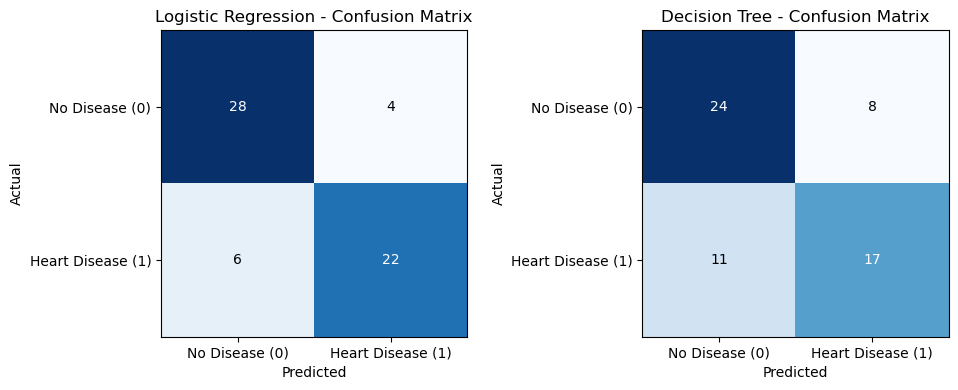

In [11]:
# Results comparison for the two models on test data
print("Test Accuracy Results")
print(f"Logistic Regression test accuracy: {log_reg_test_acc:.4f}")
print(f"Decision Tree test accuracy:       {dec_tree_test_acc:.4f}")

# Bar chart: test accuracy comparison
model_names = ['Logistic Regression', 'Decision Tree']
test_scores = [log_reg_test_acc, dec_tree_test_acc]

plt.figure(figsize=(7, 5))
bars = plt.bar(model_names, test_scores, color=['#4C72B0', '#DD8452'])
plt.ylim(0, 1.0)
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy Comparison')

for bar, score in zip(bars, test_scores):
    plt.text(bar.get_x() + bar.get_width()/2, score + 0.02, f"{score:.3f}",
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Confusion matrices for both models
y_pred_lr = log_reg.predict(X_test_scaled)
y_pred_dt = dec_tree.predict(X_test_scaled)

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_dt = confusion_matrix(y_test, y_pred_dt)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, cm, title in zip(
    axes,
    [cm_lr, cm_dt],
    ['Logistic Regression - Confusion Matrix', 'Decision Tree - Confusion Matrix']
 ):
    im = ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['No Disease (0)', 'Heart Disease (1)'])
    ax.set_yticklabels(['No Disease (0)', 'Heart Disease (1)'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)

plt.tight_layout()
plt.show()

---
## Deliverable 3: Model Evaluation (30 pts)

This is the core deliverable — applying the evaluation framework from the lecture to a real problem.

### Instructions

#### Part A: Confusion Matrix (8 pts)

For the **better-performing model** from D2:
1. Compute the confusion matrix using `confusion_matrix(y_test, y_pred)`
2. Visualize it as a **heatmap** (see the Hints section for code)
3. Label the axes clearly: "No Disease (0)" and "Heart Disease (1)"
4. **[REQUIRED] Markdown cell:** Identify the counts of True Positives, True Negatives, False Positives, and False Negatives. In the medical context, what does each one mean?

#### Part B: Classification Report (7 pts)

1. Print the full `classification_report(y_test, y_pred)`
2. **[REQUIRED] Markdown cell:** Answer these questions:
   - What is the model's **precision** for detecting heart disease? What does this number mean in plain English?
   - What is the model's **recall** for detecting heart disease? What does this number mean?
   - Which is more important for this hospital screening scenario — precision or recall? Why?

#### Part C: Cross-Validation (6 pts)

1. Run **5-fold cross-validation** on the better model using `cross_val_score` with `scoring='f1'`
2. Report the **mean** and **standard deviation** of the F1 scores across folds
3. **[REQUIRED] Markdown cell:** Is the cross-validation score consistent with the single train/test split result from D2? What would a high standard deviation across folds suggest?

#### Part D: The Overfitting Curve (9 pts)

1. Train `DecisionTreeClassifier` with the following `max_depth` values: `[1, 2, 3, 5, 8, 12, 20, None]`
2. For each value, compute both **training accuracy** and **test accuracy**
3. **Plot** training accuracy and test accuracy vs. `max_depth` on the same axes (use different colors and a legend)
4. **[REQUIRED] Markdown cell:** What is the best `max_depth` value? What happens when the tree is too shallow (underfitting)? What happens when it is too deep (overfitting)? Connect this to the lecture.

| Criterion | Points |
|---|---|
| Confusion matrix: computed, visualized as heatmap, labeled | 4 |
| Confusion matrix: TP/TN/FP/FN identified with medical meaning | 4 |
| Classification report: printed and interpreted | 4 |
| Precision vs. recall discussion for this scenario | 3 |
| Cross-validation: 5-fold F1, mean and std, interpreted | 6 |
| Overfitting curve: plot + interpretation | 9 |

Confusion Matrix (Logistic Regression):
[[28  4]
 [ 6 22]]


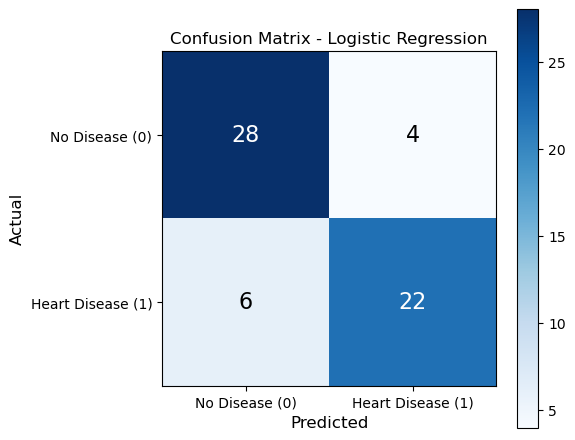

In [12]:
# Part A: Confusion matrix for the better model (Logistic Regression)
y_pred = log_reg.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix (Logistic Regression):")
print(cm)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=16,
                color='white' if cm[i, j] > cm.max()/2 else 'black')

ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Disease (0)', 'Heart Disease (1)'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['No Disease (0)', 'Heart Disease (1)'])
ax.set_title('Confusion Matrix - Logistic Regression')
plt.colorbar(im)
plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

- **True Positives (TP): 22 patients** - The model correctly predicted heart disease. In medical terms, these are high-risk patients correctly flagged for further testing.
- **True Negatives (TN): 28 patients** - The model correctly predicted no heart disease. These patients are correctly not flagged.
- **False Positives (FP): 4 patients** - The model predicted heart disease, but the patient was actually healthy. This leads to extra follow-up tests/resources but is generally safer than missing a real case.
- **False Negatives (FN): 6 patients** - The model predicted no disease, but the patient actually had heart disease. This is the most dangerous error because a real patient may be missed and treatment may be delayed.

In [ ]:
# Part B: Classification report


### Classification Report Interpretation

- **Precision for heart disease (class 1):** *What does this mean in plain English?*

-- how precise our model. if there is no false positive (we predicited the desease but actually none) it 100percent precisie.
- **Recall for heart disease (class 1):** *What does this mean in plain English?*

-- this is a measure of sensitivity, if the model misses disesed people as healthy it is not sensitive
- **Which is more important here — precision or recall?** *Why? Think about the hospital director's quote from the scenario.*

-- low precision could be costly, but low recall means we say people your healty but actually not.


In [13]:
# Part C: 5-fold cross-validation
cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=5, scoring='f1')

print("5-Fold Cross-Validation (Logistic Regression)")
print(f"F1 scores per fold: {cv_scores}")
print(f"Mean F1: {cv_scores.mean():.4f}")
print(f"Std F1:  {cv_scores.std():.4f}")

5-Fold Cross-Validation (Logistic Regression)
F1 scores per fold: [0.93023256 0.86956522 0.8        0.73170732 0.64864865]
Mean F1: 0.7960
Std F1:  0.0993


### Cross-Validation Interpretation

The cross-validation result should be compared with the single train/test split from D2. If the mean F1 score is close to the test-set F1 score, that suggests the model is reasonably stable and generalizes consistently.

A high standard deviation across folds would suggest the model's performance changes a lot depending on which samples are in the training fold. That usually means the model is sensitive to the data split and may not generalize reliably.

In [ ]:
# Part D: Overfitting curve - Decision Tree with varying max_depth
depths = [1, 2, 3, 5, 8, 12, 20, None]
train_accs = []
test_accs = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train_scaled, y_train)
    train_accs.append(model.score(X_train_scaled, y_train))
    test_accs.append(model.score(X_test_scaled, y_test))

depth_labels = [str(depth) if depth is not None else 'None' for depth in depths]

print("Decision Tree accuracy by max_depth:")
for label, train_acc, test_acc in zip(depth_labels, train_accs, test_accs):
    print(f"max_depth={label:>4} | train accuracy={train_acc:.4f} | test accuracy={test_acc:.4f}")

In [ ]:
# Plot the overfitting curve: train and test accuracy vs max_depth
plt.figure(figsize=(8, 5))
plt.plot(depth_labels, train_accs, marker='o', linewidth=2, label='Training Accuracy')
plt.plot(depth_labels, test_accs, marker='o', linewidth=2, label='Test Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Overfitting Curve')
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Overfitting Curve Interpretation

*What is the best `max_depth`? What happens when the tree is too shallow? Too deep? Connect to the lecture.*


---
## Deliverable 4: Medical Implications & Reflection (25 pts)

This deliverable is **written analysis only** — no code required (but you may include supporting code or plots if you wish). Answer **all four questions** in the markdown cells below.

### Instructions

| Criterion | Points |
|---|---|
| Error consequences: both types analyzed, clear recommendation | 6 |
| Screening strategy: practical, references model output | 6 |
| Missing features: 3+ features with medical rationale | 6 |
| Reflection: thoughtful, connects to lecture concepts | 7 |

### Question 1: Error Consequences (6 pts)

Consider these two types of model errors:

- **Type A (False Negative):** The model predicts "No Disease" but the patient actually **has** heart disease.
- **Type B (False Positive):** The model predicts "Heart Disease" but the patient is actually **healthy**.

Which type of error is more dangerous? Which type wastes more hospital resources? If you were advising the hospital, which type of error would you prioritize reducing, and why? *(1 paragraph)*

---

*Your answer here...*


### Question 2: Screening Strategy (6 pts)

The hospital has capacity to refer only **50 patients per month** for advanced cardiac testing (stress tests, angiograms, etc.). In a typical month, they see 300 patients for routine check-ups.

Using your model's predictions, describe a strategy to select which 50 patients to refer. Would you trust the model's predictions on their own, or would you combine them with other information? *(1 paragraph)*

---

*Your answer here...*


### Question 3: Missing Information (6 pts)

Name at least **3 features** that are NOT in this dataset but would likely improve the model's ability to predict heart disease. For each, briefly explain why it would be useful. *(Bullet points)*

---

- *Feature 1:*
- *Feature 2:*
- *Feature 3:*


### Question 4: Reflection (7 pts)

What was the most surprising or interesting thing you learned in this lab about how ML models are evaluated? Before this lab, would you have trusted a model that reports "85% accuracy"? How has your understanding changed? *(1–2 paragraphs)*

---

*Your answer here...*


---
## Hints

### Handling Missing Values

```python
print(f"Missing values per column:\n{df.isnull().sum()}")
print(f"\nShape before: {df.shape}")
df = df.dropna()
print(f"Shape after:  {df.shape}")
```

### Train-Test Split with Stratification

```python
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
```

### StandardScaler (Fit on Train Only!)

```python
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit AND transform on train
X_test_scaled = scaler.transform(X_test)          # only transform on test
```

### Timing Model Training

```python
start = time.time()
model.fit(X_train_scaled, y_train)
train_time = time.time() - start
print(f"Training time: {train_time:.4f} seconds")
```

### Confusion Matrix Heatmap

```python
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

# Add count annotations
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=18,
                color='white' if cm[i, j] > cm.max()/2 else 'black')

ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Disease (0)', 'Heart Disease (1)'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['No Disease (0)', 'Heart Disease (1)'])
ax.set_title('Confusion Matrix')
plt.colorbar(im)
plt.tight_layout()
plt.show()
```

### Cross-Validation

```python
scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')
print(f"F1 scores per fold: {scores}")
print(f"Mean F1: {scores.mean():.4f} (+/- {scores.std():.4f})")
```

### Overfitting Curve

```python
depths = [1, 2, 3, 5, 8, 12, 20, None]
train_accs = []
test_accs = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_scaled, y_train)
    train_accs.append(dt.score(X_train_scaled, y_train))
    test_accs.append(dt.score(X_test_scaled, y_test))

# For plotting, replace None with a label
depth_labels = [str(d) if d is not None else 'None' for d in depths]
```

---
## Grading

| Component | Points |
|-----------|--------|
| D1: Data Loading & Exploration | 20 |
| D2: Data Preparation & Model Training | 25 |
| D3: Model Evaluation | 30 |
| D4: Medical Implications & Reflection | 25 |
| **Total** | **100** |

### Deductions

| Issue | Penalty |
|-------|---------|
| Notebook doesn't run top-to-bottom | -10 |
| Scaling before train-test split (data leakage) | -5 |
| Missing axis labels or units on plots (per deliverable) | -3 |
| No stratification in train-test split | -3 |
| No `random_state` set (results not reproducible) | -3 |
| Missing AI assistance acknowledgment (if used) | -2 |

## Submission

This lab is **individual work**.

1. Rename this notebook to `Week06_Lab_FirstnameLastname.ipynb`
2. Make sure your notebook **runs from top to bottom without errors** (Kernel → Restart & Run All)
3. Commit and push to your fork:

```bash
git add Week06_Machine_Learning_Introduction/lab/Week06_Lab_FirstnameLastname.ipynb
git commit -m "Submit Week 06 lab - Heart Disease Prediction"
git push origin main
```

4. **Deadline:** Tuesday, April 7, 2026 (beginning of class)
5. **Late policy:** 10% penalty per day, maximum 3 days late

---

### Questions?

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr